# Importing libraries and Data

In [29]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve,precision_score,recall_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.layers import  Input,Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# Using 'latin-1' so that pandas can encode
df=pd.read_csv('/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv', encoding='latin-1')
df.columns = ["target", "id", "date", "query", "user", "text"]
df.head(7)

,target,id,date,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
5,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
6,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...


In [5]:
# We only need text and target columns
df=df[['text','target']].reset_index(drop=True)

# Converting 4->1 for positive 
df['target']=df['target'].replace({4:1})
df.head()

,text,target
0,is upset that he can't update his Facebook by ...,0
1,@Kenichan I dived many times for the ball. Man...,0
2,my whole body feels itchy and like its on fire,0
3,"@nationwideclass no, it's not behaving at all....",0
4,@Kwesidei not the whole crew,0


In [6]:
# Taking 150,000 data each form both positive and negative statement
df_pos=df[df['target']==1].iloc[:150000]
df_neg=df[df['target']==0].iloc[:150000]
df=pd.concat([df_pos,df_neg]).reset_index(drop=True)

In [ ]:
# Checking for null values
df.null().sum()

In [7]:
df.target.value_counts()

target
1    150000
0    150000
Name: count, dtype: int64

* ### The data is perfectly balanced having 150,000 positive statement and 150,000 negative statement 

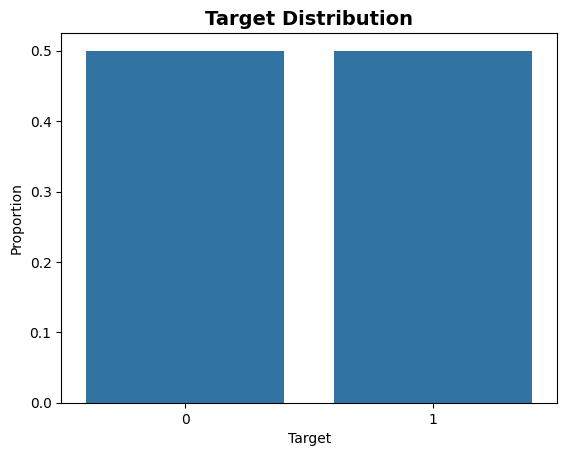

In [8]:
sns.barplot(df.target.value_counts(normalize=True))
plt.title('Target Distribution',fontweight='bold',fontsize=14)
plt.xlabel('Target')
plt.ylabel('Proportion')
plt.show()

* ### Finally data is ready for EDA(Exploratory Data Analysis)

# EDA(Exploratory Data Analysis)

In [9]:
STOP_WORDS = stopwords.words("english")

In [10]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
#Creating function to clean the text
def clean_text(text:str)->str:
  text=text.lower()
  text=re.sub(r"http\S+|www\S+|https\S+", " ", text)     #removing urls if any
  text=re.sub(r"@\w+", " ", text)                        #removing mention
  text=re.sub(r"[^a-zA-Z\s]", " ",text)                  #keep only letters
  text = re.sub(r"\s+", " ", text).strip()               
  words=text.split()                                                     
  words = [lemmatizer.lemmatize(w) for w in words if w not in STOP_WORDS]
  return " ".join(words)


In [12]:
df['clean_text']=df['text'].astype(str).apply(clean_text)
df.head()

,text,target,clean_text
0,I LOVE @Health4UandPets u guys r the best!!,1,love u guy r best
1,im meeting up with one of my besties tonight! ...,1,im meeting one besties tonight cant wait girl ...
2,"@DaRealSunisaKim Thanks for the Twitter add, S...",1,thanks twitter add sunisa got meet hin show dc...
3,Being sick can be really cheap when it hurts t...,1,sick really cheap hurt much eat real food plus...
4,@LovesBrooklyn2 he has that effect on everyone,1,effect everyone


* ### The text column is clean and now we can perform tokenization and splitting the data into train:test into 80:20 ratio

# Data Preprocessing

In [13]:
X=df['clean_text']  #text column
y=df['target']      #label column

max_len = 150
vocab_size = 25000   

# Tokenizing
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

# Sequence then pad_sequences 
seqs = tokenizer.texts_to_sequences(X)
X_pad = sequence.pad_sequences(seqs, maxlen=max_len)

#Splitting the data into train:test into 80:20 ratio
X_train,X_test,y_train,y_test=train_test_split(X_pad,y,test_size=0.2,random_state=42,stratify=y)
print(f'X_train size:{X_train.shape}')
print(f'X_test size:{X_test.shape}')
y_train.shape

X_train size:(240000, 150)
X_test size:(60000, 150)


(240000,)

* ### The training data has 240000 samples and test data has 60000 samples and we can make model using Embedding Layers,Bidirectional,LSTM and Dense with using Dropout to avoid overfitting.

# Model Building

In [14]:
# Creating model using keras' Sequential model with Embedding layers, Bidirectional, LSTM, Dense and dropout to avoid overfitting
model = Sequential()
model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=vocab_size,output_dim=256))
model.add(Bidirectional(LSTM(256, dropout=0.3,return_sequences=True)))
model.add(Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3)))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

#Compiling model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#Final summary of the model
model.summary()

I0000 00:00:1772965736.471494      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772965736.477060      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 256)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 512)       │     1,050,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,140,033 (31.05 MB)

 Trainable params: 8,140,033 (31.05 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Using callbacks to monitor validation loss 
callbacks=[
    EarlyStopping(monitor='val_loss',patience=5),
    ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3)
]

In [16]:
# Training the model
import time
start=time.time()
model.fit(X_train,y_train,epochs=5,batch_size=128,verbose=1,callbacks=callbacks,validation_split=0.2)
final=time.time()
total_time=final-start
total_time 

Epoch 1/5


I0000 00:00:1772965746.613559     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 754s 497ms/step - accuracy: 0.7125 - loss: 0.5444 - val_accuracy: 0.7706 - val_loss: 0.4730 - learning_rate: 0.0010
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 744s 496ms/step - accuracy: 0.7981 - loss: 0.4335 - val_accuracy: 0.7720 - val_loss: 0.4799 - learning_rate: 0.0010
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 744s 496ms/step - accuracy: 0.8201 - loss: 0.3910 - val_accuracy: 0.7685 - val_loss: 0.4920 - learning_rate: 0.0010
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 746s 497ms/step - accuracy: 0.8414 - loss: 0.3469 - val_accuracy: 0.7599 - val_loss: 0.5515 - learning_rate: 0.0010
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 745s 497ms/step - accuracy: 0.8714 - loss: 0.2867 - val_accuracy: 0.7544 - val_loss: 0.6424 - learning_rate: 5.0000e-04


3733.6332907676697

* ### The training accuracy is 87.14% having loss 0.28
* ### The validation accuracy is 75.44% having loss 64.24
* ### Total time taken to train model : 62 minutes or approx 1 hour

# Evaluation

In [17]:
loss,acc=model.evaluate(X_test,y_test)
print(f'Accuray :{acc*100:.2f}%')
print(f'loss :{loss}')

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 255s 135ms/step - accuracy: 0.7561 - loss: 0.6331
Accuray :75.35%
loss :0.6385652422904968


In [23]:
# Prediction on validation data and training data
y_pred_test=(model.predict(X_test)>0.5).astype(int)
y_pred_train=(model.predict(X_train)>0.5).astype(int)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 274s 146ms/step
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 1096s 146ms/step


In [24]:
y_pred_test

array([[1],
       [0],
       [1],
       ...,
       [1],
       [0],
       [1]])

In [31]:
# Different Evaluation
print(f'f1 Score : {100*(f1_score(y_test,y_pred_test)):.2f}%')
print(f'roc_auc score : {100*(roc_auc_score(y_test,y_pred_test)):.2f}%')
print(f'Precision score : {100*(precision_score(y_test,y_pred_test)):.2f}%')
print(f'Recall_score : {100*(recall_score(y_test,y_pred_test)):.2f}%')

f1 Score : 75.43%
roc_auc score : 75.35%
Precision score : 75.18%
Recall_score : 75.68%


In [33]:
# Classification report
classification_r=classification_report(y_test,y_pred_test)
print(f'The Classification Report:\n {classification_r}')

The Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.75      0.75     30000
           1       0.75      0.76      0.75     30000

    accuracy                           0.75     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.75      0.75      0.75     60000



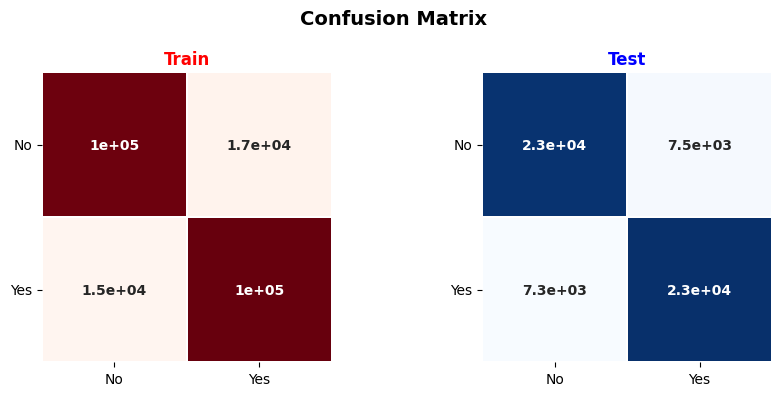

In [34]:
# Confusion Matrix
cf_mx_train = confusion_matrix(y_train, y_pred_train)
cf_mx_test = confusion_matrix(y_test, y_pred_test)

# Plotting the confusion matrices
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# Train confusion matrix
sns.heatmap(cf_mx_train,
            annot=True,
            annot_kws={'fontsize':10, 'fontweight':'bold'},
            cmap='Reds',
            cbar=False,
            square=True,
            linewidths=1.1,
            yticklabels=['No', 'Yes'],
            xticklabels=['No', 'Yes'],
            ax=ax[0])
ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=0)
ax[0].set_title("Train", fontsize=12, fontweight='bold', color='red')

# Test confusion matrix
sns.heatmap(cf_mx_test,
            annot=True,
            annot_kws={'fontsize':10, 'fontweight':'bold'},
            cmap='Blues',
            cbar=False,
            square=True,
            linewidths=1.1,
            yticklabels=['No', 'Yes'],
            xticklabels=['No', 'Yes'],
            ax=ax[1])
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=0)
ax[1].set_title("Test", fontsize=12, fontweight='bold', color='blue')

# Overall title and layout adjustment
fig.suptitle("Confusion Matrix", fontsize=14, fontweight='bold', color='black')
fig.tight_layout()
plt.show()

In [35]:
#fpr=False positive rate
#tpr=True positive rate
fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 273s 145ms/step


In [39]:
auc=roc_auc_score(y_test,y_pred_test)
auc

np.float64(0.7535)

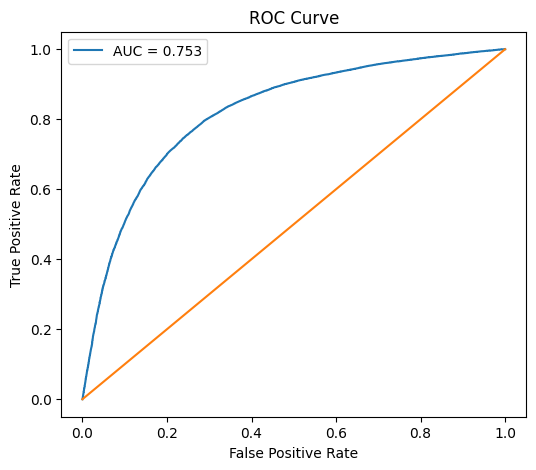

In [40]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1])  

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

* ## Final accuracy of model is 75.35%

* ### Importing the model as pickle file

In [56]:
import joblib
joblib.dump(model,'sentiment_model.pkl')
print(f'Pickle file is saved as sentiment_model.pkl')

Pickle file is saved as sentiment_model.pkl
